In [1]:
# =========================
# IMPORTS
# =========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets

from torchvision import transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader

from torch.nn.utils import spectral_norm

from torch.utils.tensorboard import SummaryWriter

In [2]:
# =========================
# CONFIG
# =========================
torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.benchmark = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 128
IMG_CHANNELS = 1

BATCH_SIZE = 8

NOISE_DIM = 128

FEATURE_GEN = 32
FEATURE_CRITIC = 32

LR = 1e-4

EPOCHS = 200

CRITIC_ITERATIONS = 5

LAMBDA_GP = 10

print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
import cv2
import os

INPUT_FOLDER = "photonic_images/classA"
OUTPUT_FOLDER = "processed_photonic/classA"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

image_files = os.listdir(INPUT_FOLDER)

for file in image_files:

    path = os.path.join(INPUT_FOLDER, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # ====================================
    # RESIZE
    # ====================================

    img = cv2.resize(img, (128, 128))

    # ====================================
    # LIGHT DENOISE
    # ====================================

    img = cv2.GaussianBlur(img, (3, 3), 0)

    # ====================================
    # LIGHT CONTRAST ENHANCEMENT
    # ====================================

    img = cv2.equalizeHist(img)

    # ====================================
    # SAVE
    # ====================================

    out_path = os.path.join(OUTPUT_FOLDER, file)

    cv2.imwrite(out_path, img)

print("Preprocessing complete.")

Preprocessing complete.


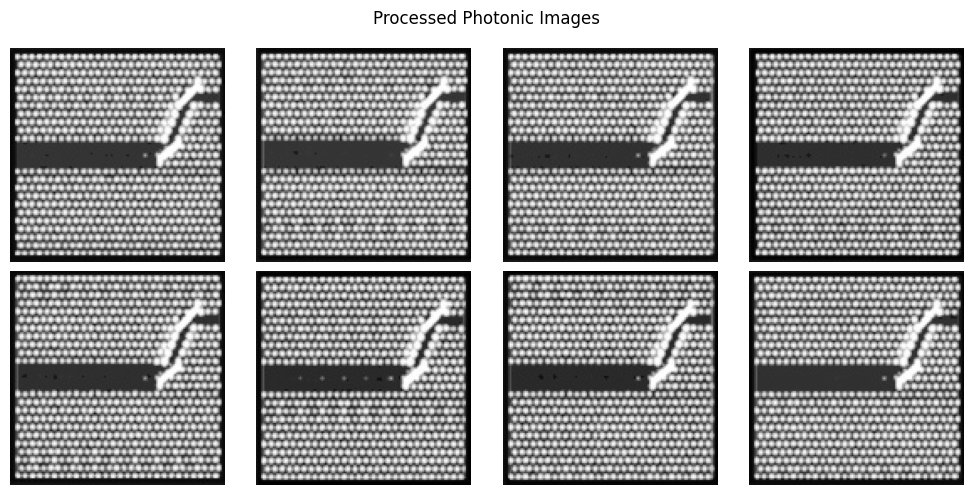

In [4]:
# =========================
# SHOW PREPROCESSED IMAGES
# =========================

files = os.listdir(OUTPUT_FOLDER)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flatten()):

    img = cv2.imread(
        os.path.join(OUTPUT_FOLDER, files[i]),
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Processed Photonic Images")
plt.tight_layout()

plt.show()

In [5]:
# =========================
# TRANSFORMS
# =========================

transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=1),

    transforms.ToTensor(),

    transforms.Resize((128, 128)),

    transforms.Normalize(
        [0.5],
        [0.5]
    )
])

# =========================
# DATASET
# =========================

dataset = datasets.ImageFolder(
    root="processed_photonic",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    num_workers=2,
    drop_last=True
)

print("Dataset Size:", len(dataset))

Dataset Size: 34


In [6]:
# =========================
# GENERATOR
# =========================
class Generator(nn.Module):

    def __init__(self, noise_dim, channels_img, features_g):

        super().__init__()

        self.net = nn.Sequential(

            # 1x1 -> 4x4
            self._block(noise_dim, features_g * 16, 4, 1, 0),

            # 4 -> 8
            self._block(features_g * 16, features_g * 8, 4, 2, 1),

            # 8 -> 16
            self._block(features_g * 8, features_g * 4, 4, 2, 1),

            # 16 -> 32
            self._block(features_g * 4, features_g * 2, 4, 2, 1),

            # 32 -> 64
            self._block(features_g * 2, features_g, 4, 2, 1),

            # 64 -> 128
            nn.ConvTranspose2d(
                features_g,
                channels_img,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def _block(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride,
        padding
    ):

        return nn.Sequential(

            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(True)
        )

    def forward(self, x):

        x = x.view(x.shape[0], x.shape[1], 1, 1)

        return self.net(x)
    # =========================
# CRITIC
# =========================
class Critic(nn.Module):

    def __init__(self, channels_img, features_d):

        super().__init__()

        self.net = nn.Sequential(

            # 128 -> 64
            spectral_norm(
                nn.Conv2d(
                    channels_img,
                    features_d,
                    4,
                    2,
                    1
                )
            ),

            nn.LeakyReLU(0.2),

            # 64 -> 32
            self._block(features_d, features_d * 2),

            # 32 -> 16
            self._block(features_d * 2, features_d * 4),

            # 16 -> 8
            self._block(features_d * 4, features_d * 8),

            # 8 -> 4
            self._block(features_d * 8, features_d * 16),

            # 4 -> 1
            spectral_norm(
                nn.Conv2d(
                    features_d * 16,
                    1,
                    kernel_size=4,
                    stride=1,
                    padding=0
                )
            )
        )

    def _block(self, in_channels, out_channels):

        return nn.Sequential(

            spectral_norm(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False
                )
            ),

            nn.LeakyReLU(0.2)
        )

    def forward(self, x):

        return self.net(x).reshape(-1)



def initialize_weights(model):

    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight.data, 1)
            nn.init.constant_(m.bias.data, 0)
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [7]:
# =========================
# GRADIENT PENALTY
# =========================

def gradient_penalty(critic, real, fake, device):

    BATCH_SIZE, C, H, W = real.shape

    epsilon = torch.rand(
        (BATCH_SIZE, 1, 1, 1)
    ).repeat(1, C, H, W).to(device)

    interpolated_images = real * epsilon + fake * (1 - epsilon)

    interpolated_images.requires_grad_(True)

    mixed_scores = critic(interpolated_images)

    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient = gradient.reshape(gradient.shape[0], -1)

    gradient_norm = gradient.norm(2, dim=1)

    gp = torch.mean((gradient_norm - 1) ** 2)

    return gp

In [8]:
# =========================
# INIT MODELS
# =========================

gen = Generator(
    NOISE_DIM,
    IMG_CHANNELS,
    FEATURE_GEN
).to(DEVICE)

initialize_weights(gen)

critic = Critic(
    IMG_CHANNELS,
    FEATURE_CRITIC
).to(DEVICE)

initialize_weights(critic)

opt_gen = optim.Adam(
    gen.parameters(),
    lr=LR,
    betas=(0.0, 0.9)
)

opt_critic = optim.Adam(
    critic.parameters(),
    lr=LR,
    betas=(0.0, 0.9)
)

fixed_noise = torch.randn(
    32,
    NOISE_DIM
).to(DEVICE)

In [9]:
# =========================
# TENSORBOARD
# =========================

writer_real = SummaryWriter("logs/real")
writer_fake = SummaryWriter("logs/fake")

step = 0

In [10]:
real, _ = next(iter(loader))

print(real.shape)

torch.Size([8, 1, 128, 128])


In [11]:
# =========================
# TRAINING LOOP
# =========================

gen.train()
critic.train()

for epoch in range(EPOCHS):

    for batch_idx, (real, _) in enumerate(loader):

        real = real.to(DEVICE)

        cur_batch_size = real.shape[0]

        # =========================================
        # TRAIN CRITIC MULTIPLE TIMES
        # =========================================

        for _ in range(CRITIC_ITERATIONS):

            noise = torch.randn(
                  cur_batch_size,
                  NOISE_DIM
                  ).to(DEVICE)
            
            fake = gen(noise)

            critic_real = critic(real)

            critic_fake = critic(fake.detach())

            gp = gradient_penalty(
                critic,
                real,
                fake.detach(),
                DEVICE
            )

            loss_critic = (
                -(torch.mean(critic_real))
                + torch.mean(critic_fake)
                + LAMBDA_GP * gp
            )

            critic.zero_grad()

            loss_critic.backward()

            opt_critic.step()

        # =========================================
        # TRAIN GENERATOR
        # =========================================

        noise = torch.randn(
            cur_batch_size,
            NOISE_DIM
        ).to(DEVICE)

        fake = gen(noise)

        gen_fake = critic(fake)

        loss_gen = -torch.mean(gen_fake)

        gen.zero_grad()

        loss_gen.backward()

        opt_gen.step()

    # =========================================
    # PRINT LOSSES
    # =========================================

    print(
            f"EPOCH [{epoch}/{EPOCHS}] "
            f"Loss Critic: {loss_critic:.4f}, "
            f"Loss Gen: {loss_gen:.4f}"
        )

    with torch.no_grad():

            fake = gen(fixed_noise)

            fake = fake * 0.5 + 0.5

            real_grid = torchvision.utils.make_grid(
                real[:16],
                normalize=True
            )

            fake_grid = torchvision.utils.make_grid(
                fake[:16],
                normalize=True
            )

            writer_real.add_image(
                "Real",
                real_grid,
                global_step=step
            )

            writer_fake.add_image(
                "Fake",
                fake_grid,
                global_step=step
            )

            step += 1

EPOCH [0/200] Loss Critic: -49.1890, Loss Gen: -12.7891
EPOCH [1/200] Loss Critic: -107.8414, Loss Gen: -28.9384
EPOCH [2/200] Loss Critic: -133.6202, Loss Gen: -31.7323
EPOCH [3/200] Loss Critic: -137.2315, Loss Gen: -36.4297
EPOCH [4/200] Loss Critic: -150.5037, Loss Gen: -39.7436
EPOCH [5/200] Loss Critic: -145.1731, Loss Gen: -35.7819
EPOCH [6/200] Loss Critic: -152.2969, Loss Gen: -34.7631
EPOCH [7/200] Loss Critic: -161.8167, Loss Gen: -41.1289
EPOCH [8/200] Loss Critic: -161.3205, Loss Gen: -45.3788
EPOCH [9/200] Loss Critic: -152.8784, Loss Gen: -41.2578
EPOCH [10/200] Loss Critic: -162.2312, Loss Gen: -37.8962
EPOCH [11/200] Loss Critic: -165.6617, Loss Gen: -39.7705
EPOCH [12/200] Loss Critic: -167.4204, Loss Gen: -43.3984
EPOCH [13/200] Loss Critic: -177.8804, Loss Gen: -49.6062
EPOCH [14/200] Loss Critic: -168.6748, Loss Gen: -48.8834
EPOCH [15/200] Loss Critic: -172.9408, Loss Gen: -51.9728
EPOCH [16/200] Loss Critic: -180.5992, Loss Gen: -50.2056
EPOCH [17/200] Loss Criti

In [12]:
# =========================
# GENERATE IMAGES
# =========================

os.makedirs("generated_images", exist_ok=True)

gen.eval()

with torch.no_grad():

    noise = torch.randn(
        200,
        NOISE_DIM
    ).to(DEVICE)

    fake_images = gen(noise)

    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

    for i in range(200):

        save_image(
            fake_images[i],
            f"generated_images/generated_{i}.png"
        )

print("200 images generated.")

200 images generated.


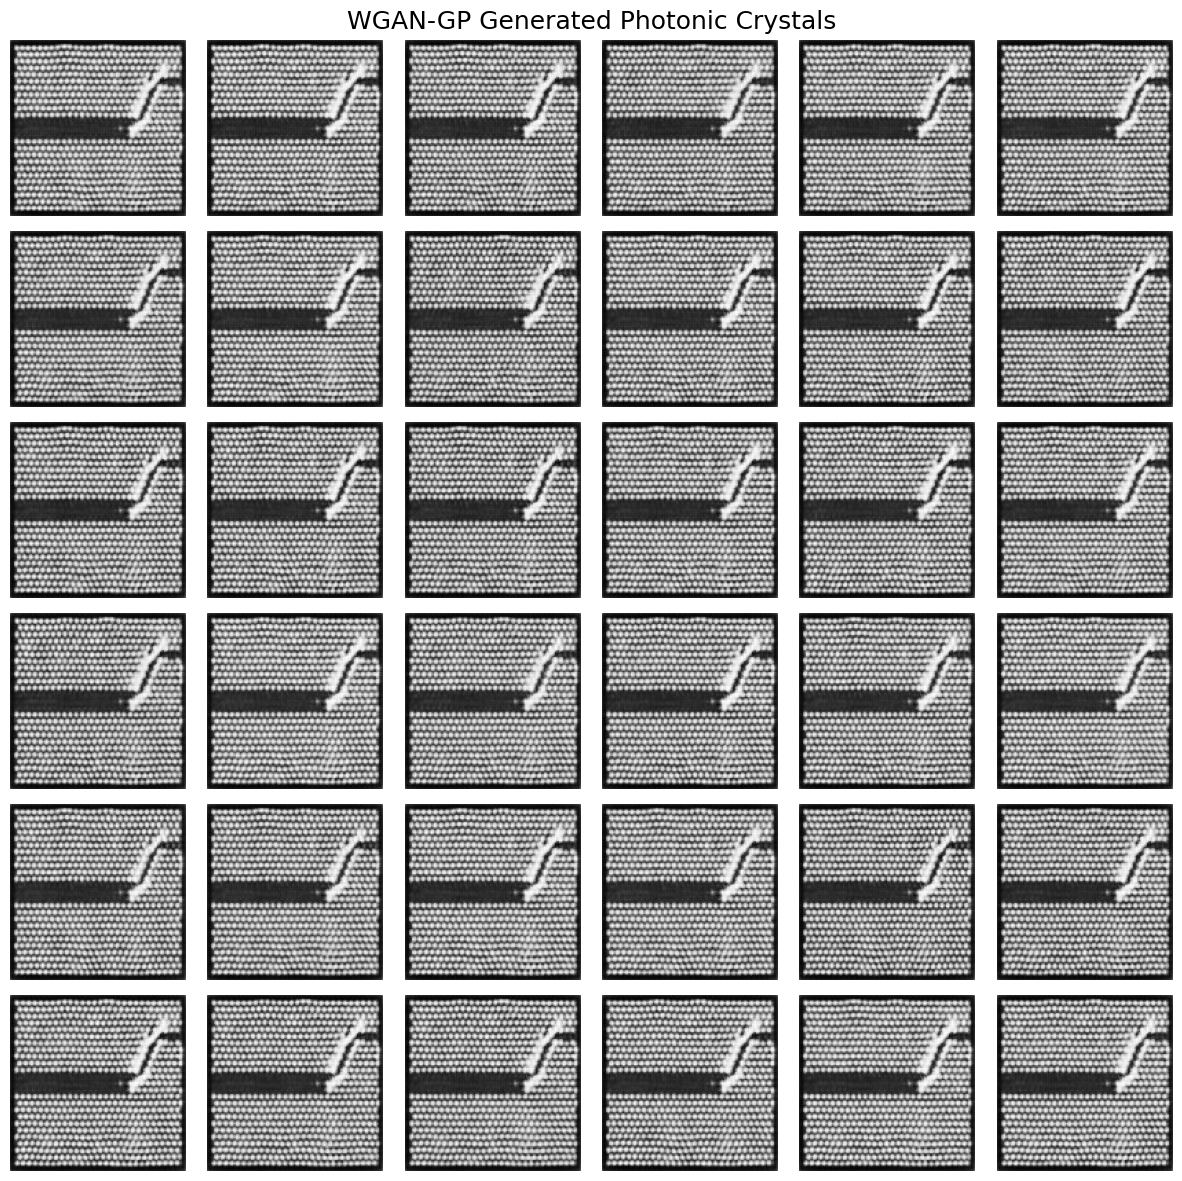

In [13]:
# =========================
# VISUALIZE GENERATED IMAGES
# =========================

gen.eval()

with torch.no_grad():

    noise = torch.randn(
        36,
        NOISE_DIM
    ).to(DEVICE)

    samples = gen(noise)

    samples = (samples * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(6, 6, figsize=(12, 12))

for i, ax in enumerate(axes.flatten()):

    ax.imshow(
        samples[i].cpu().squeeze(),
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "WGAN-GP Generated Photonic Crystals",
    fontsize=18
)

plt.tight_layout()

plt.show()